<a href="https://colab.research.google.com/github/sanamjain3/GitHubGraduation-2021/blob/main/Copy_of_Data_Analytics_Olistsmart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

from google.colab import files
uploaded = files.upload()

olist = pd.read_csv("Case_1_dataset.csv.csv")

# Quick sanity check
print(olist.head())
print(olist.shape)          # (rows, columns)
print(olist.columns.tolist())



Saving Case_1_dataset.csv.csv to Case_1_dataset.csv (1).csv
                           order_id                       customer_id  \
0  00010242fe8c5a6d1ba2dd792cb16214  871766c5855e863f6eccc05f988b23cb   
1  00018f77f2f0320c557190d7a144bdd3  eb28e67c4c0b83846050ddfb8a35d051   
2  000229ec398224ef6ca0657da4fc703e  3818d81c6709e39d06b2738a8d3a2474   
3  00024acbcdf0a6daa1e931b038114c75  af861d436cfc08b2c2ddefd0ba074622   
4  00042b26cf59d7ce69dfabb4e55b4fd9  64b576fb70d441e8f1b2d7d446e483c5   

           customer_city customer_state                         seller_id  \
0  campos dos goytacazes             RJ  48436dade18ac8b2bce089ec2a041202   
1        santa fe do sul             SP  dd7ddc04e1b6c2c614352b383efe2d36   
2          para de minas             MG  5b51032eddd242adc84c38acab88f23d   
3                atibaia             SP  9d7a1d34a5052409006425275ba1c2b4   
4        varzea paulista             SP  df560393f3a51e74553ab94004ba5c87   

                         product_id pr

In [ ]:
na_count = olist.isna().sum()
print("The number of missing values for each column")
print(na_count)

dup_count = olist.duplicated().sum()
print("The number of duplicated rows is", dup_count)

olist.info()

print(olist.columns)



The number of missing values for each column
order_id                            0
customer_id                         0
customer_city                       0
customer_state                      0
seller_id                           0
product_id                          0
product_category                    0
product_price                       0
order_quantity                      0
total_price                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  14
order_delivered_carrier_date     1028
order_delivered_customer_date    2230
review_score                      797
review_answer_timestamp           797
dtype: int64
The number of duplicated rows is 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102425 entries, 0 to 102424
Data columns (total 17 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id               

In [ ]:
import pandas as pd
from datetime import datetime as dt

olist = pd.read_csv("Case_1_dataset.csv.csv")

ts_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "review_answer_timestamp"
]
for col in ts_cols:
    olist[col] = pd.to_datetime(olist[col], errors="coerce", dayfirst=True)

seq_errors = (
    (olist["order_approved_at"] < olist["order_purchase_timestamp"]) |
    (olist["order_delivered_carrier_date"] < olist["order_approved_at"]) |
    (olist["order_delivered_customer_date"] < olist["order_delivered_carrier_date"])
)
print(f"Sequence-violation rows removed: {seq_errors.sum()}")
olist = olist[~seq_errors].copy()

# delivery_days: purchase → customer delivery (full customer experience)
olist["delivery_days"] = (
    olist["order_delivered_customer_date"] - olist["order_purchase_timestamp"]
).dt.total_seconds() / 86400

# approval_hours: purchase → approval
olist["approval_hours"] = (
    olist["order_approved_at"] - olist["order_purchase_timestamp"]
).dt.total_seconds() / 3600

# carrier_handoff_days: approved → carrier pick-up
olist["carrier_handoff_days"] = (
    olist["order_delivered_carrier_date"] - olist["order_approved_at"]
).dt.total_seconds() / 86400

# purchase_month and year for trend analysis
olist["purchase_month"] = olist["order_purchase_timestamp"].dt.month_name().str[:3]
olist["purchase_year"]  = olist["order_purchase_timestamp"].dt.year

impossible = (olist["delivery_days"] <= 0) | (olist["approval_hours"] < 0)
print(f"Impossible delivery time rows removed: {impossible.sum()}")
olist = olist[~impossible].copy()

# Drop rows where delivery timestamps are missing (non-delivered can't be compared fairly)
olist_delivered = olist[olist["order_status"] == "delivered"].dropna(
    subset=["order_delivered_customer_date", "review_score"]
).copy()

# Separate delivered vs non-delivered for fair comparisons
olist_nondelivered = olist[olist["order_status"] != "delivered"].copy()
print(f"Delivered orders: {len(olist_delivered)}")
print(f"Non-delivered orders: {len(olist_nondelivered)}")

Q1 = olist_delivered["delivery_days"].quantile(0.25)
Q3 = olist_delivered["delivery_days"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

outliers_delivery = olist_delivered[
    (olist_delivered["delivery_days"] < lower_bound) |
    (olist_delivered["delivery_days"] > upper_bound)
]
print(f"Delivery outliers flagged: {len(outliers_delivery)}")
olist_clean = olist_delivered[
    (olist_delivered["delivery_days"] >= lower_bound) &
    (olist_delivered["delivery_days"] <= upper_bound)
].copy()
print(f"Clean delivered dataset rows: {len(olist_clean)}")

# Count how many times each customer_id appears in delivered + paid orders
purchase_counts = (
    olist_clean
    .groupby("customer_id")["order_id"]
    .nunique()
    .reset_index()
)
purchase_counts.columns = ["customer_id", "order_count"]
olist_clean = olist_clean.merge(purchase_counts, on="customer_id", how="left")
olist_clean["repeat_buyer"] = (olist_clean["order_count"] >= 2).astype(int)  # 1 = repeat, 0 = one-time

repeat_rate = olist_clean["repeat_buyer"].mean()
print(f"Repeat purchase rate: {repeat_rate:.2%}")

# Compute first purchase date per customer
first_purchase = (
    olist_clean
    .groupby("customer_id")["order_purchase_timestamp"]
    .min()
    .reset_index()
    .rename(columns={"order_purchase_timestamp": "first_purchase_date"})
)
second_purchase = (
    olist_clean
    .sort_values("order_purchase_timestamp")
    .groupby("customer_id", as_index=False)
    .nth(1)
    [["customer_id", "order_purchase_timestamp"]]
    .rename(columns={"order_purchase_timestamp": "second_purchase_date"})
)
repeat_timing = first_purchase.merge(second_purchase, on="customer_id", how="inner")
repeat_timing["days_1_to_2"] = (
    repeat_timing["second_purchase_date"] - repeat_timing["first_purchase_date"]
).dt.total_seconds() / 86400
print(repeat_timing["days_1_to_2"].describe())

olist_clean = olist_clean.drop_duplicates()

olist_encoded = pd.get_dummies(
    olist_clean,
    columns=["product_category", "customer_state"],
    drop_first=True
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_vars = ["delivery_days", "approval_hours", "carrier_handoff_days",
            "product_price", "order_quantity", "review_score"]
vif_data = olist_clean[vif_vars].dropna()
vif_df = pd.DataFrame({
    "Variable": vif_vars,
    "VIF": [
        variance_inflation_factor(vif_data.values, i)
        for i in range(len(vif_vars))
    ]
})
print("\nVIF Results (>10 indicates severe multicollinearity):")
print(vif_df)


Sequence-violation rows removed: 1469
Impossible delivery time rows removed: 0
Delivered orders: 98042
Non-delivered orders: 2220
Delivery outliers flagged: 1370
Clean delivered dataset rows: 96671
Repeat purchase rate: 6.23%
count    5374.000000
mean       38.505675
std        86.386603
min         0.000000
25%         0.000000
50%         0.000000
75%        22.164583
max       582.863889
Name: days_1_to_2, dtype: float64

VIF Results (>10 indicates severe multicollinearity):
               Variable       VIF
0         delivery_days  3.776934
1        approval_hours  1.283019
2  carrier_handoff_days  2.200803
3         product_price  1.541150
4        order_quantity  4.933746
5          review_score  4.798521


In [ ]:
olist_clean[["delivery_days", "approval_hours", "carrier_handoff_days",
             "product_price", "order_quantity", "total_price",
             "review_score"]].describe(include="all")

print("=== KEY KPIs ===")
print(f"Total orders:          {olist_clean['order_id'].nunique():,}")
print(f"Total customers:       {olist_clean['customer_id'].nunique():,}")
print(f"Total sellers:         {olist_clean['seller_id'].nunique():,}")
print(f"Total revenue (£):     {olist_clean['total_price'].sum():,.2f}")
print(f"Median delivery days:  {olist_clean['delivery_days'].median():.1f}")
print(f"Repeat purchase rate:  {repeat_rate:.2%}")
print(f"Avg review score:      {olist_clean['review_score'].mean():.2f}")

olist_clean.groupby("repeat_buyer")[
    ["delivery_days", "approval_hours", "review_score", "product_price"]
].agg(["mean", "median", "std"])

olist_clean["review_score"].value_counts(normalize=True).sort_index()

olist_clean["repeat_buyer"].value_counts()
olist_clean["repeat_buyer"].value_counts(normalize=True)

olist_clean["product_category"].value_counts().head(15)

olist["order_status"].value_counts()

pd.crosstab(olist_clean["review_score"], olist_clean["repeat_buyer"],
            normalize="index", margins=True)

pd.crosstab(olist_clean["product_category"], olist_clean["repeat_buyer"],
            normalize="index").sort_values(1, ascending=False).head(15)




=== KEY KPIs ===
Total orders:          93,113
Total customers:       90,156
Total sellers:         2,943
Total revenue (£):     14,806,944.11
Median delivery days:  10.1
Repeat purchase rate:  6.23%
Avg review score:      4.16


repeat_buyer,0,1
product_category,,
arts_and_craftmanship,0.782609,0.217391
home_appliances,0.826446,0.173554
la_cuisine,0.833333,0.166667
fashion_childrens_clothes,0.857143,0.142857
fashion_male_clothing,0.877193,0.122807
furniture_bedroom,0.877778,0.122222
furniture_mattress_and_upholstery,0.878788,0.121212
fashion_bags_accessories,0.879915,0.120085
music,0.888889,0.111111


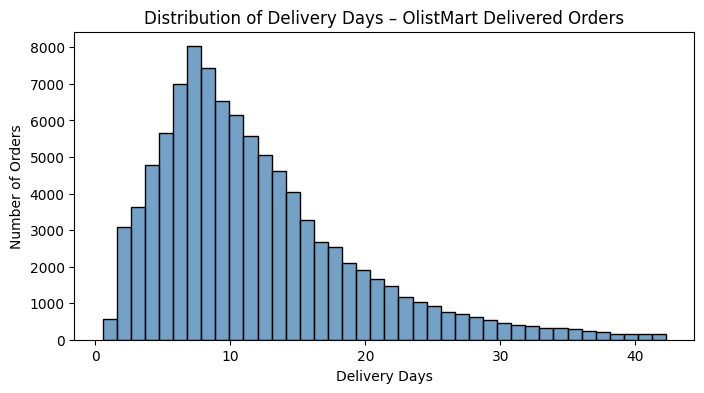

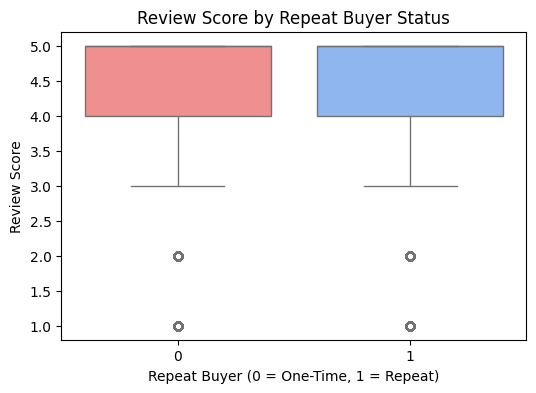

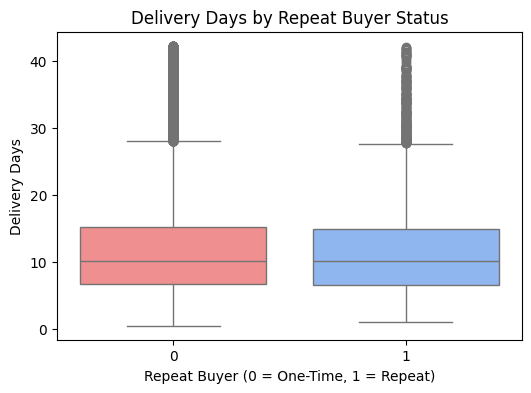

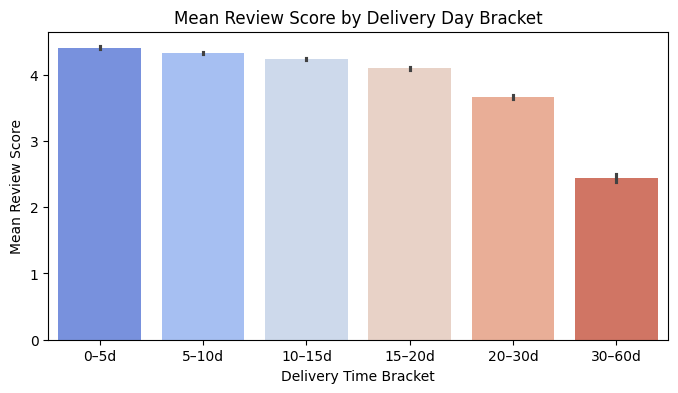

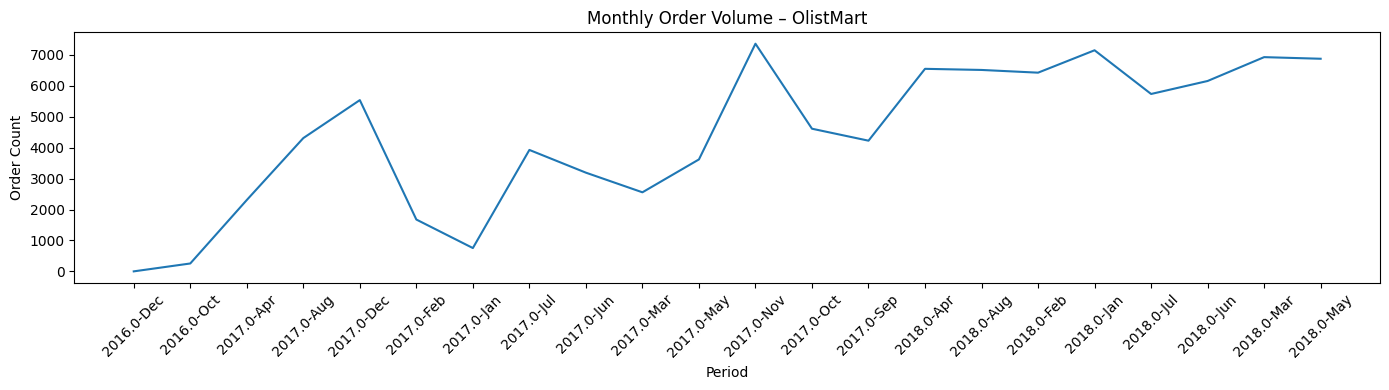

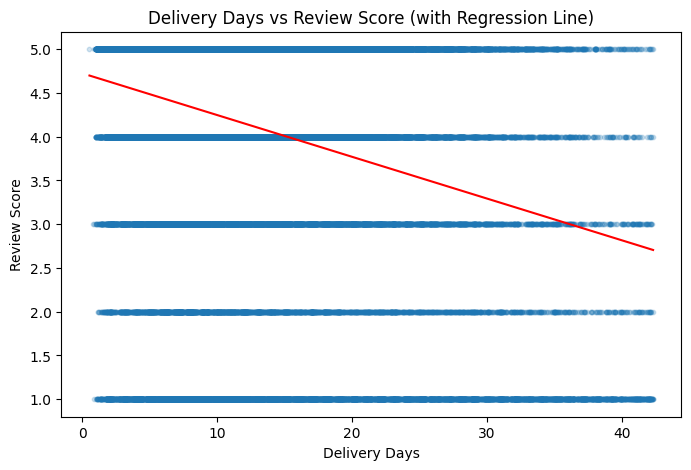

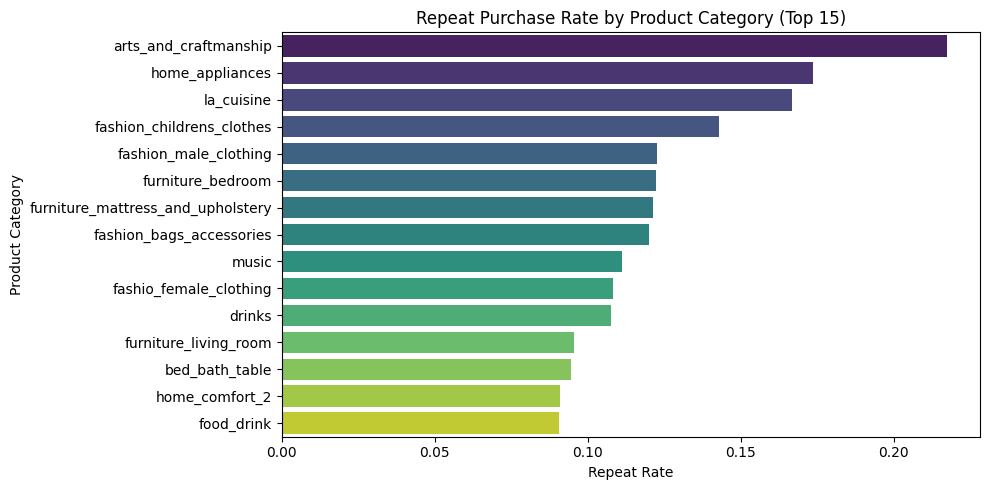

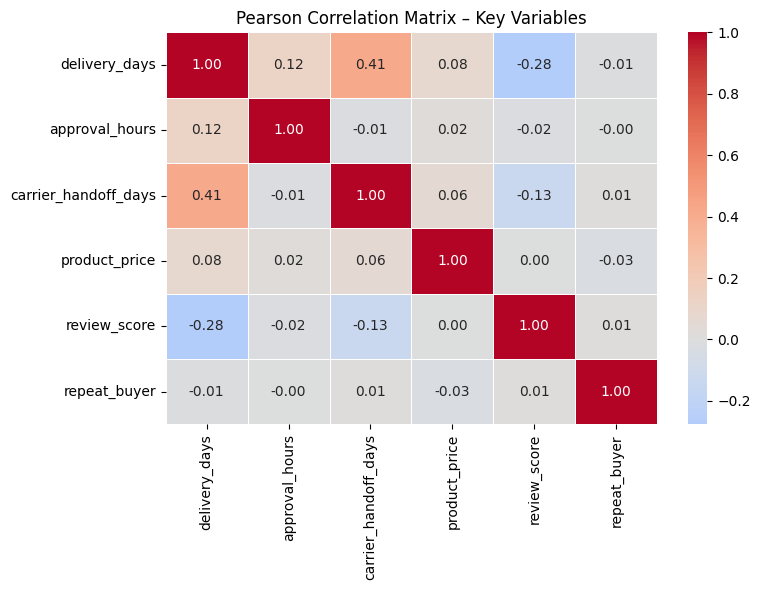

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(data=olist_clean, x="delivery_days", bins=40, color="steelblue")
plt.title("Distribution of Delivery Days – OlistMart Delivered Orders")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=olist_clean, x="repeat_buyer", y="review_score",
            palette=["#FF7F7F", "#7FB3FF"])
plt.title("Review Score by Repeat Buyer Status")
plt.xlabel("Repeat Buyer (0 = One-Time, 1 = Repeat)")
plt.ylabel("Review Score")
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=olist_clean, x="repeat_buyer", y="delivery_days",
            palette=["#FF7F7F", "#7FB3FF"])
plt.title("Delivery Days by Repeat Buyer Status")
plt.xlabel("Repeat Buyer (0 = One-Time, 1 = Repeat)")
plt.ylabel("Delivery Days")
plt.show()

olist_clean["delivery_bracket"] = pd.cut(
    olist_clean["delivery_days"],
    bins=[0, 5, 10, 15, 20, 30, 60],
    labels=["0–5d", "5–10d", "10–15d", "15–20d", "20–30d", "30–60d"]
)
plt.figure(figsize=(8, 4))
sns.barplot(data=olist_clean, x="delivery_bracket", y="review_score",
            estimator="mean", errorbar=("ci", 95), palette="coolwarm")
plt.title("Mean Review Score by Delivery Day Bracket")
plt.xlabel("Delivery Time Bracket")
plt.ylabel("Mean Review Score")
plt.show()

monthly_orders = (
    olist_clean
    .groupby(["purchase_year", "purchase_month"])["order_id"]
    .count()
    .reset_index(name="order_count")
)
monthly_orders["period"] = monthly_orders["purchase_year"].astype(str) + "-" + monthly_orders["purchase_month"]
plt.figure(figsize=(14, 4))
sns.lineplot(data=monthly_orders, x="period", y="order_count", estimator="sum")
plt.title("Monthly Order Volume – OlistMart")
plt.xticks(rotation=45)
plt.xlabel("Period")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(data=olist_clean, x="delivery_days", y="review_score",
            line_kws={"color": "red", "linewidth": 1.5},
            scatter_kws={"alpha": 0.2, "s": 10}, ci=None)
plt.title("Delivery Days vs Review Score (with Regression Line)")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.show()

cat_repeat = (
    olist_clean.groupby("product_category")["repeat_buyer"]
    .mean()
    .reset_index()
    .sort_values("repeat_buyer", ascending=False)
    .head(15)
)
plt.figure(figsize=(10, 5))
sns.barplot(data=cat_repeat, x="repeat_buyer", y="product_category",
            palette="viridis")
plt.title("Repeat Purchase Rate by Product Category (Top 15)")
plt.xlabel("Repeat Rate")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

corr_vars = ["delivery_days", "approval_hours", "carrier_handoff_days",
             "product_price", "review_score", "repeat_buyer"]
corr_matrix = olist_clean[corr_vars].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5)
plt.title("Pearson Correlation Matrix – Key Variables")
plt.tight_layout()
plt.show()



=== PEARSON CORRELATIONS ===
  Pearson delivery_days vs review_score: r = -0.276, p-value = 0.0000
  Pearson approval_hours vs review_score: r = -0.018, p-value = 0.0000
  Pearson carrier_handoff_days vs review_score: r = -0.134, p-value = 0.0000
  Pearson delivery_days vs repeat_buyer: r = -0.008, p-value = 0.0194
  Pearson review_score vs repeat_buyer: r = 0.012, p-value = 0.0002
  Pearson product_price vs review_score: r = 0.002, p-value = 0.4585

=== SPEARMAN CORRELATIONS ===
  Spearman delivery_days vs review_score: rho = -0.200, p-value = 0.0000
  Spearman approval_hours vs review_score: rho = -0.008, p-value = 0.0109
  Spearman carrier_handoff_days vs review_score: rho = -0.090, p-value = 0.0000
  Spearman delivery_days vs repeat_buyer: rho = -0.004, p-value = 0.2024
  Spearman review_score vs repeat_buyer: rho = 0.016, p-value = 0.0000
  Spearman product_price vs review_score: rho = 0.006, p-value = 0.0538

=== KENDALL CORRELATIONS ===
  Kendall delivery_days vs review_score: t

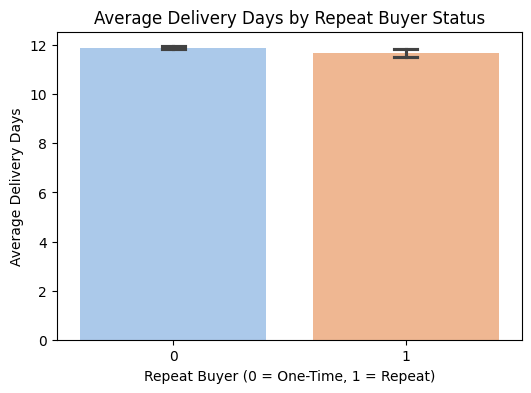

In [ ]:
print("=== PEARSON CORRELATIONS ===")
pairs = [
    ("delivery_days", "review_score"),
    ("approval_hours", "review_score"),
    ("carrier_handoff_days", "review_score"),
    ("delivery_days", "repeat_buyer"),
    ("review_score", "repeat_buyer"),
    ("product_price", "review_score"),
]
for v1, v2 in pairs:
    subset = olist_clean[[v1, v2]].dropna()
    r, p = stats.pearsonr(subset[v1], subset[v2])
    print(f"  Pearson {v1} vs {v2}: r = {r:.3f}, p-value = {p:.4f}")

print("\n=== SPEARMAN CORRELATIONS ===")
for v1, v2 in pairs:
    subset = olist_clean[[v1, v2]].dropna()
    rho, p = stats.spearmanr(subset[v1], subset[v2])
    print(f"  Spearman {v1} vs {v2}: rho = {rho:.3f}, p-value = {p:.4f}")

print("\n=== KENDALL CORRELATIONS ===")
for v1, v2 in pairs:
    subset = olist_clean[[v1, v2]].dropna()
    tau, p = stats.kendalltau(subset[v1], subset[v2])
    print(f"  Kendall {v1} vs {v2}: tau = {tau:.3f}, p-value = {p:.4f}")

from scipy.stats import chi2_contingency

# Binarise review score (high ≥ 4, low < 4)
olist_clean["review_high"] = (olist_clean["review_score"] >= 4).astype(int)

cross_table = pd.crosstab(olist_clean["review_high"], olist_clean["repeat_buyer"])
print("\nCross-tabulation: High Review Score vs Repeat Buyer")
print(cross_table, "\n")

chi2, p, dof, _ = chi2_contingency(cross_table)
print(f"Chi-square = {chi2:.3f}, df = {dof}, p-value = {p:.4f}")

group_repeat   = olist_clean.loc[olist_clean["repeat_buyer"] == 1, "delivery_days"]
group_onetime  = olist_clean.loc[olist_clean["repeat_buyer"] == 0, "delivery_days"]

ttest = stats.ttest_ind(group_repeat, group_onetime, equal_var=False)
print(f"\nT-test (Delivery Days: Repeat vs One-Time)")
print(f"  Mean – Repeat: {group_repeat.mean():.2f}d | One-Time: {group_onetime.mean():.2f}d")
print(f"  t-stat = {ttest[0]:.3f}, p-value = {ttest[1]:.4f}")

# Visualise T-test result
plt.figure(figsize=(6, 4))
sns.barplot(data=olist_clean, x="repeat_buyer", y="delivery_days",
            order=[0, 1], errorbar=("ci", 95), capsize=0.1, palette="pastel")
plt.title("Average Delivery Days by Repeat Buyer Status")
plt.xlabel("Repeat Buyer (0 = One-Time, 1 = Repeat)")
plt.ylabel("Average Delivery Days")
plt.show()





In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import numpy as np

# Work on clean subset with no NaNs in key columns
reg_data = olist_clean[[
    "review_score", "repeat_buyer", "delivery_days", "approval_hours",
    "carrier_handoff_days", "product_price", "order_quantity",
    "product_category", "customer_state"
]].dropna().copy()

# Sanitise column names for formula API
reg_data.columns = [c.replace(" ", "_").replace("-", "_") for c in reg_data.columns]

results = []

# Examines what drives customer satisfaction
ols_model = smf.ols(
    "review_score ~ delivery_days + approval_hours + carrier_handoff_days + "
    "product_price + order_quantity + C(product_category) + C(customer_state)",
    data=reg_data
).fit(maxiter=1000)
results.append(ols_model)
print("\n=== LINEAR REGRESSION: DV = review_score ===")
print(ols_model.summary())

# Examines what predicts repeat purchase
logit_model = smf.logit(
    "repeat_buyer ~ delivery_days + approval_hours + carrier_handoff_days + "
    "review_score + product_price + C(customer_state)",
    data=reg_data
).fit(maxiter=1000, disp=False)
results.append(logit_model)
print("\n=== LOGISTIC REGRESSION: DV = repeat_buyer ===")
print(logit_model.summary())

result_table = summary_col(
    results=results,
    float_format="%0.3f",
    stars=True,
    model_names=["Linear (Review Score)", "Logistic (Repeat Buyer)"],
    info_dict={"N": lambda x: f"{int(x.nobs)}"}
)
print(result_table)

odds_ratios = np.exp(logit_model.params)
conf = np.exp(logit_model.conf_int())
conf["Odds Ratio"] = odds_ratios
print("\nOdds Ratios (Logistic Regression):")
print(conf[["Odds Ratio", 0, 1]].rename(columns={0: "2.5%", 1: "97.5%"}))


=== LINEAR REGRESSION: DV = review_score ===
                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     104.0
Date:                Mon, 11 May 2026   Prob (F-statistic):               0.00
Time:                        13:00:17   Log-Likelihood:            -1.5605e+05
No. Observations:               96656   AIC:                         3.123e+05
Df Residuals:                   96553   BIC:                         3.133e+05
Df Model:                         102                                         
Covariance Type:            nonrobust                                         
                                                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

In [ ]:
# Helper functions (using def / lambda as per cheat sheet)
num_vars = ["delivery_days", "approval_hours", "carrier_handoff_days",
            "product_price", "order_quantity"]
cat_vars = ["product_category", "customer_state"]
candidate_vars = num_vars + cat_vars
Y = "repeat_buyer"

def term_of(v):
    """Return formula term: plain name for numeric, C(v) for categorical."""
    return v if v in num_vars else f"C({v})"

def fit_aic(formula, data):
    """Fit logistic model and return (AIC, fitted model)."""
    model = smf.logit(formula=formula, data=data).fit(disp=False)
    return model.aic, model

def make_formula(selected_vars, Y):
    """Build a statsmodels formula string from a list of selected variables."""
    base_formula = f"{Y} ~ 1"
    if not selected_vars:
        return base_formula
    terms = " + ".join([term_of(v) for v in selected_vars])
    return f"{Y} ~ {terms}"

base_formula = f"{Y} ~ 1"
selected = []
best_aic = np.inf
best_model = None
remaining = candidate_vars.copy()

best_aic, best_model = fit_aic(base_formula, reg_data)
improved = True

while improved and remaining:
    improved = False
    best_this_round = (best_aic, None, None)

    for v in remaining:
        try:
            formula_try = make_formula(selected + [v], Y)
            aic_try, model_try = fit_aic(formula_try, reg_data)
            if aic_try < best_this_round[0] - 1e-8:
                best_this_round = (aic_try, v, model_try)
        except Exception:
            continue

    if best_this_round[1] is not None:
        best_aic, v_add, best_model = best_this_round
        selected.append(v_add)
        remaining.remove(v_add)
        improved = True

print("\n=== FORWARD AIC SELECTION ===")
print("Forward-selected variables:", selected)
print(f"Best AIC: {best_aic:.2f}")
print(best_model.summary())

selected_sb = []
best_aic_sb = np.inf
best_model_sb = None
remaining_sb = candidate_vars.copy()
best_aic_sb, best_model_sb = fit_aic(base_formula, reg_data)
improved_sb = True

while improved_sb:
    improved_sb = False

# Forward step
    best_forward = (best_aic_sb, None, None)
    for v in list(remaining_sb):
        try:
            formula_try = make_formula(selected_sb + [v], Y)
            aic_try, model_try = fit_aic(formula_try, reg_data)
            if aic_try < best_forward[0] - 1e-8:
                best_forward = (aic_try, v, model_try)
        except Exception:
            continue

    if best_forward[1] is not None:
        best_aic_sb, v_add, best_model_sb = best_forward
        selected_sb.append(v_add)
        remaining_sb.remove(v_add)
        improved_sb = True

# Backward step
        changed = True
        while changed and len(selected_sb) > 1:
            changed = False
            best_backward = (best_aic_sb, None, None)
            for v in list(selected_sb):
                try:
                    cand = [x for x in selected_sb if x != v]
                    formula_try = make_formula(cand, Y)
                    aic_try, model_try = fit_aic(formula_try, reg_data)
                    if aic_try < best_backward[0] - 1e-8:
                        best_backward = (aic_try, v, model_try)
                except Exception:
                    continue
            if best_backward[1] is not None:
                best_aic_sb, v_remove, best_model_sb = best_backward
                selected_sb.remove(v_remove)
                improved_sb = True
                changed = True

print("\n=== STEPWISE (FORWARD + BACKWARD) AIC SELECTION ===")
print("Stepwise-selected variables:", selected_sb)
print(f"Best AIC: {best_aic_sb:.2f}")
print(best_model_sb.summary())

# Lambda for churn probability label
churn_label = lambda prob: "High Risk" if prob >= 0.7 else ("Medium Risk" if prob >= 0.4 else "Low Risk")

reg_data["churn_probability"] = best_model_sb.predict(reg_data)
reg_data["churn_risk_segment"] = reg_data["churn_probability"].apply(churn_label)
print(reg_data[["churn_probability", "churn_risk_segment"]].value_counts())





/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


=== FORWARD AIC SELECTION ===
Forward-selected variables: ['product_category', 'product_price', 'order_quantity', 'carrier_handoff_days']
Best AIC: 44360.71
                           Logit Regression Results                           
Dep. Variable:           repeat_buyer   No. Observations:                96656
Model:                          Logit   Df Residuals:                    96581
Method:                           MLE   Df Model:                           74
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.02001
Time:                        11:39:21   Log-Likelihood:                -22105.
converged:                      False   LL-Null:                       -22557.
Covariance Type:            nonrobust   LLR p-value:                1.002e-142
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op


=== STEPWISE (FORWARD + BACKWARD) AIC SELECTION ===
Stepwise-selected variables: ['product_category', 'product_price', 'order_quantity', 'carrier_handoff_days']
Best AIC: 44360.71
                           Logit Regression Results                           
Dep. Variable:           repeat_buyer   No. Observations:                96656
Model:                          Logit   Df Residuals:                    96581
Method:                           MLE   Df Model:                           74
Date:                Mon, 11 May 2026   Pseudo R-squ.:                 0.02001
Time:                        11:42:27   Log-Likelihood:                -22105.
converged:                      False   LL-Null:                       -22557.
Covariance Type:            nonrobust   LLR p-value:                1.002e-142
                                                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              roc_auc_score, RocCurveDisplay)
import pandas as pd
import numpy as np

# Re-initialize olist_clean since it was lost in the kernel
# Note: This reproduces the cleaning logic from cell 1dlpnxyRqaJX
olist = pd.read_csv("Case_1_dataset.csv.csv")
ts_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "review_answer_timestamp"]
for col in ts_cols:
    olist[col] = pd.to_datetime(olist[col], errors="coerce", dayfirst=True)

seq_errors = (olist["order_approved_at"] < olist["order_purchase_timestamp"]) | (olist["order_delivered_carrier_date"] < olist["order_approved_at"]) | (olist["order_delivered_customer_date"] < olist["order_delivered_carrier_date"])
olist = olist[~seq_errors].copy()

olist["delivery_days"] = (olist["order_delivered_customer_date"] - olist["order_purchase_timestamp"]).dt.total_seconds() / 86400
olist["approval_hours"] = (olist["order_approved_at"] - olist["order_purchase_timestamp"]).dt.total_seconds() / 3600
olist["carrier_handoff_days"] = (olist["order_delivered_carrier_date"] - olist["order_approved_at"]).dt.total_seconds() / 86400

olist_delivered = olist[olist["order_status"] == "delivered"].dropna(subset=["order_delivered_customer_date", "review_score"]).copy()
Q1, Q3 = olist_delivered["delivery_days"].quantile(0.25), olist_delivered["delivery_days"].quantile(0.75)
IQR = Q3 - Q1
olist_clean = olist_delivered[(olist_delivered["delivery_days"] >= Q1 - 3*IQR) & (olist_delivered["delivery_days"] <= Q3 + 3*IQR)].copy()

purchase_counts = olist_clean.groupby("customer_id")["order_id"].nunique().reset_index()
purchase_counts.columns = ["customer_id", "order_count"]
olist_clean = olist_clean.merge(purchase_counts, on="customer_id", how="left")
olist_clean["repeat_buyer"] = (olist_clean["order_count"] >= 2).astype(int)

# Now proceed with ML data preparation
ml_data = olist_clean[[
    "repeat_buyer", "delivery_days", "approval_hours",
    "carrier_handoff_days", "product_price", "order_quantity",
    "review_score", "product_category", "customer_state"
]].dropna().copy()

ml_data = pd.get_dummies(ml_data, columns=["product_category", "customer_state"], drop_first=True)
X = ml_data.drop(columns=["repeat_buyer"])
y = ml_data["repeat_buyer"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf)],
    "AUC-ROC": [roc_auc_score(y_test, y_prob_dt), roc_auc_score(y_test, y_prob_rf)]
})
display(model_comparison)

,Model,Accuracy,AUC-ROC
0,Decision Tree,0.740835,0.569843
1,Random Forest,0.714384,0.621778



=== DECISION TREE ===
Accuracy: 0.7344708524689082
AUC     : 0.5626410992537123
              precision    recall  f1-score   support

           0       0.95      0.76      0.84     27955
           1       0.09      0.37      0.15      1876

    accuracy                           0.73     29831
   macro avg       0.52      0.57      0.50     29831
weighted avg       0.89      0.73      0.80     29831



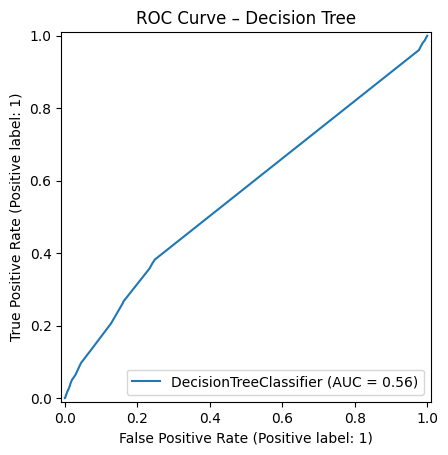


=== RANDOM FOREST ===
Accuracy: 0.7216318594750427
AUC     : 0.6175671645604667
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     27955
           1       0.10      0.43      0.16      1876

    accuracy                           0.72     29831
   macro avg       0.53      0.58      0.50     29831
weighted avg       0.90      0.72      0.79     29831



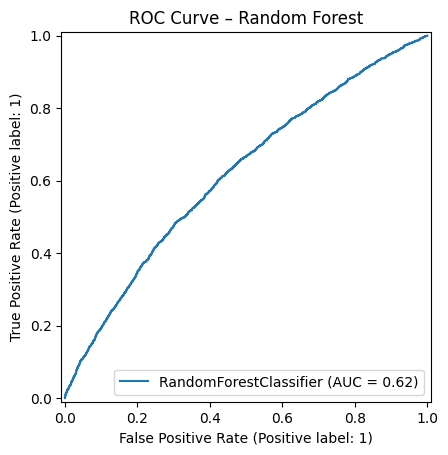

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              roc_auc_score, RocCurveDisplay)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- 1. Data Re-initialization ---
# Loading and cleaning to ensure 'olist_clean' exists
olist = pd.read_csv("Case_1_dataset.csv.csv")
ts_cols = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"]
for col in ts_cols:
    olist[col] = pd.to_datetime(olist[col], errors="coerce", dayfirst=True)

# Basic cleaning logic consistent with previous steps
seq_errors = (olist["order_approved_at"] < olist["order_purchase_timestamp"]) | (olist["order_delivered_customer_date"] < olist["order_delivered_carrier_date"])
olist = olist[~seq_errors].copy()

olist["delivery_days"] = (olist["order_delivered_customer_date"] - olist["order_purchase_timestamp"]).dt.total_seconds() / 86400
olist["approval_hours"] = (olist["order_approved_at"] - olist["order_purchase_timestamp"]).dt.total_seconds() / 3600
olist["carrier_handoff_days"] = (olist["order_delivered_carrier_date"] - olist["order_approved_at"]).dt.total_seconds() / 86400

olist_clean = olist[olist["order_status"] == "delivered"].dropna(subset=["order_delivered_customer_date", "review_score"]).copy()

# Repeat buyer logic
purchase_counts = olist_clean.groupby("customer_id")["order_id"].nunique().reset_index()
purchase_counts.columns = ["customer_id", "order_count"]
olist_clean = olist_clean.merge(purchase_counts, on="customer_id", how="left")
olist_clean["repeat_buyer"] = (olist_clean["order_count"] >= 2).astype(int)

# --- 2. ML Data Prep ---
ml_data = olist_clean[[
    "repeat_buyer", "delivery_days", "approval_hours",
    "carrier_handoff_days", "product_price", "order_quantity",
    "review_score", "product_category", "customer_state"
]].dropna().copy()

ml_data = pd.get_dummies(ml_data, columns=["product_category", "customer_state"], drop_first=True)

X = ml_data.drop(columns=["repeat_buyer"])
y = ml_data["repeat_buyer"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# --- 3. Decision Tree ---
dt_model = DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("\n=== DECISION TREE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("AUC     :", roc_auc_score(y_test, y_prob_dt))
print(classification_report(y_test, y_pred_dt))

RocCurveDisplay.from_estimator(dt_model, X_test, y_test)
plt.title("ROC Curve – Decision Tree")
plt.show()

# --- 4. Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC     :", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("ROC Curve – Random Forest")
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. Handle Categorical data for SMOTE (already done in ml_data via get_dummies)
# 2. Initialize SMOTE
smote = SMOTE(random_state=42)

# 3. Resample the training data only
X_res, y_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {y_train.value_counts().to_dict()}")
print(f"Resampled training shape: {y_res.value_counts().to_dict()}")

# 4. Train Random Forest on the oversampled data
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf_smote.fit(X_res, y_res)

# 5. Evaluate on the original (unseen) test set
y_pred_smote = rf_smote.predict(X_test)
y_prob_smote = rf_smote.predict_proba(X_test)[:, 1]

print("\n=== RANDOM FOREST WITH SMOTE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("AUC     :", roc_auc_score(y_test, y_prob_smote))
print(classification_report(y_test, y_pred_smote))

Original training shape: {0: 65227, 1: 4377}
Resampled training shape: {0: 65227, 1: 65227}

=== RANDOM FOREST WITH SMOTE ===
Accuracy: 0.8357413428983272
AUC     : 0.5972148831182005
              precision    recall  f1-score   support

           0       0.94      0.88      0.91     27955
           1       0.10      0.21      0.14      1876

    accuracy                           0.84     29831
   macro avg       0.52      0.54      0.52     29831
weighted avg       0.89      0.84      0.86     29831



In [ ]:
# Based on diagnostic thresholds from regression and correlation analysis

def churn_intervention_rule(row):
    """
    Heuristic rule engine for targeted retention interventions.
    Returns the recommended action for each customer order.
    """
    if row["delivery_days"] > 15 and row["review_score"] <= 2:
        return "Priority Recovery: Apology voucher + free express next order"
    elif row["delivery_days"] > 10 and row["review_score"] <= 3:
        return "Proactive Outreach: Discount code within 30-day window"
    elif row["review_score"] >= 4 and row["repeat_buyer"] == 0:
        return "Loyalty Nudge: Personalised recommendation email"
    elif row["approval_hours"] > 48:
        return "Operational Alert: Seller approval SLA breach – flag seller"
    else:
        return "Standard: No immediate action required"

olist_clean["retention_action"] = olist_clean.apply(churn_intervention_rule, axis=1)
print(olist_clean["retention_action"].value_counts())

# Recommends products based on what similar customers (by review history) bought
from sklearn.neighbors import NearestNeighbors

# Build customer-product matrix (pivot: customers × product categories)
customer_cat = olist_clean.pivot_table(
    index="customer_id",
    columns="product_category",
    values="review_score",
    aggfunc="mean",
    fill_value=0
)

knn = NearestNeighbors(n_neighbors=6, metric="cosine", algorithm="brute")
knn.fit(customer_cat.values)

def get_user_recommendations(customer_id, n_recs=5):
    """Return top-N product category recommendations for a given customer."""
    if customer_id not in customer_cat.index:
        return "Customer not found"
    idx = customer_cat.index.get_loc(customer_id)
    distances, indices = knn.kneighbors(
        customer_cat.iloc[idx].values.reshape(1, -1), n_neighbors=6
    )
    similar_customers = customer_cat.index[indices.flatten()[1:]]
# Aggregate category scores from similar customers
    recs = customer_cat.loc[similar_customers].mean().sort_values(ascending=False)
# Exclude categories the customer already bought
    already_bought = customer_cat.loc[customer_id][customer_cat.loc[customer_id] > 0].index
    recs = recs.drop(already_bought, errors="ignore")
    return recs.head(n_recs)

# Example: get recommendations for the first customer in the dataset
sample_customer = customer_cat.index[0]
print(f"\nUser-Based KNN Recommendations for customer {sample_customer}:")
print(get_user_recommendations(sample_customer))

# Recommends categories similar to what a customer already bought

# Transpose: product categories × customers
item_matrix = customer_cat.T

knn_item = NearestNeighbors(n_neighbors=6, metric="cosine", algorithm="brute")
knn_item.fit(item_matrix.values)

def get_item_recommendations(product_category, n_recs=5):
    """Return top-N similar product categories for a given category."""
    if product_category not in item_matrix.index:
        return "Category not found"
    idx = item_matrix.index.get_loc(product_category)
    distances, indices = knn_item.kneighbors(
        item_matrix.iloc[idx].values.reshape(1, -1), n_neighbors=6
    )
    similar_cats = item_matrix.index[indices.flatten()[1:]]
    return similar_cats.tolist()[:n_recs]

# Example: items similar to "health_beauty"
print("\nItem-Based KNN Recommendations for 'health_beauty':")
print(get_item_recommendations("health_beauty"))




retention_action
Loyalty Nudge: Personalised recommendation email                72687
Standard: No immediate action required                          12025
Proactive Outreach: Discount code within 30-day window           7510
Priority Recovery: Apology voucher + free express next order     6709
Operational Alert: Seller approval SLA breach – flag seller       521
Name: count, dtype: int64

User-Based KNN Recommendations for customer 0000366f3b9a7992bf8c76cfdf3221e2:
product_category
agro_industry_and_commerce    0.0
art                           0.0
air_conditioning              0.0
arts_and_craftmanship         0.0
audio                         0.0
dtype: float64

Item-Based KNN Recommendations for 'health_beauty':
['perfumery', 'sports_leisure', 'drinks', 'bed_bath_table', 'tablets_printing_image']


In [ ]:
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. State-level review analysis
state_review = olist_clean.groupby("customer_state")["review_score"].agg(
    ["mean", "std", "count"]
).sort_values("mean")
print("\nReview Score by Customer State (Top/Bottom 10):")
print(pd.concat([state_review.head(5), state_review.tail(5)]))

# 2. State-level delivery analysis
state_delivery = olist_clean.groupby("customer_state")["delivery_days"].agg(
    ["mean", "median", "count"]
).sort_values("mean", ascending=False)
print("\nDelivery Days by State (Slowest 10):")
print(state_delivery.head(10))

# 3. Logistic Regression with Interaction Term
# Using ml_data as it is defined in the current environment
interaction_model = smf.logit(
    "repeat_buyer ~ delivery_days * review_score + product_price",
    data=ml_data
).fit()
print("\n=== INTERACTION TERM CHECK (delivery_days & review_score) ===")
print(interaction_model.summary())

# 4. Final VIF Check for multicollinearity
vif_cols = ["delivery_days", "approval_hours", "carrier_handoff_days", "product_price", "order_quantity"]
vif_final = olist_clean[vif_cols].dropna()
vif_df_final = pd.DataFrame({
    "Variable": vif_final.columns,
    "VIF": [variance_inflation_factor(vif_final.values, i) for i in range(vif_final.shape[1])]
})
print("\nFinal VIF Check:")
print(vif_df_final)


Review Score by Customer State (Top/Bottom 10):
                    mean       std  count
customer_state                           
MA              3.778378  1.491362    740
AL              3.833747  1.481109    403
PA              3.894081  1.441585    963
SE              3.900293  1.459865    341
RR              3.902439  1.374861     41
MG              4.166510  1.275139  11705
PR              4.210558  1.237535   5058
AM              4.216216  1.248349    148
SP              4.217164  1.235612  41890
AP              4.217391  1.055372     69

Delivery Days by State (Slowest 10):
                     mean     median  count
customer_state                             
RR              29.387517  25.007639     41
AP              29.168186  24.346528     69
AM              26.346692  25.862500    148
AL              24.260567  21.985417    403
PA              23.604461  21.025000    963
SE              21.351067  17.957639    341
MA              21.280198  19.048264    740
CE           

In [ ]:
# Install plotnine if not already installed
# !pip install plotnine -q

from plotnine import (ggplot, aes, geom_bar, geom_col, coord_flip,
                       theme_minimal, labs, scale_fill_manual, theme,
                       element_text, stat_summary)

# ggplot2-style: Mean Repeat Rate by Top 10 Product Categories
top_cats = (
    olist_clean.groupby("product_category")["repeat_buyer"]
    .mean()
    .reset_index()
    .rename(columns={"repeat_buyer": "repeat_rate"})
    .sort_values("repeat_rate", ascending=False)
    .head(10)
)

p = (
    ggplot(top_cats, aes(x="reorder(product_category, repeat_rate)", y="repeat_rate"))
    + geom_col(fill="#2E86AB", alpha=0.85)
    + coord_flip()
    + theme_minimal()
    + labs(
        title="Repeat Purchase Rate by Product Category (Top 10)",
        x="Product Category",
        y="Repeat Rate"
    )
    + theme(figure_size=(9, 5), axis_text=element_text(size=9))
)
print(p)





<ggplot: (900 x 500)>


### Feature Engineering: RFM and Customer Lifetime Value (CLV)
We will calculate:
1. **Recency**: Days since the last purchase.
2. **Frequency**: Number of unique orders.
3. **Monetary**: Total spent by the customer.
4. **CLV**: A basic estimate combining frequency and monetary value.

In [ ]:
# Reference date for recency (day after the last purchase in the dataset)
reference_date = olist_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = olist_clean.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'total_price': 'sum'
}).reset_index()

rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Basic CLV: (Average Order Value * Frequency)
rfm['avg_order_value'] = rfm['monetary'] / rfm['frequency']
rfm['clv_score'] = rfm['monetary'] # In this context, total spend is our proxy for historical CLV

# Merge back to the main cleaned dataset
olist_clean = olist_clean.merge(rfm[['customer_id', 'recency', 'frequency', 'monetary', 'clv_score']], on='customer_id', how='left')

print("RFM and CLV features added. Summary of CLV scores:")
display(olist_clean[['recency', 'frequency', 'monetary', 'clv_score']].describe())

RFM and CLV features added. Summary of CLV scores:


,recency,frequency,monetary,clv_score
count,99451.000000,99452.000000,99452.000000,99452.000000
mean,236.956049,1.077927,174.602646,174.602646
std,152.383455,0.381075,235.328240,235.328240
min,1.000000,1.000000,9.590000,9.590000
25%,114.000000,1.000000,65.010000,65.010000
50%,218.000000,1.000000,113.560000,113.560000
75%,345.000000,1.000000,193.900000,193.900000
max,714.000000,15.000000,13664.080000,13664.080000


In [ ]:
# 1. Update ML Data: Removing 'leaking' features (frequency, monetary, clv_score)
# These features contain the answer to 'is this a repeat buyer', leading to AUC 1.0
ml_data_v2 = olist_clean[[
    'repeat_buyer', 'delivery_days', 'approval_hours',
    'carrier_handoff_days', 'product_price', 'order_quantity',
    'review_score', 'product_category', 'customer_state',
    'recency' # Recency is okay as it represents time since last purchase
]].dropna().copy()

ml_data_v2 = pd.get_dummies(ml_data_v2, columns=['product_category', 'customer_state'], drop_first=True)

X_v2 = ml_data_v2.drop(columns=['repeat_buyer'])
y_v2 = ml_data_v2['repeat_buyer'].astype(int)

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(X_v2, y_v2, test_size=0.3, stratify=y_v2, random_state=42)

# 2. Retrain XGBoost with leak-free feature set
xgb_v2 = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=15,
    objective='binary:logistic',
    random_state=42,
    eval_metric='auc'
)
xgb_v2.fit(X_train_v2, y_train_v2)

# 3. Performance Comparison
y_prob_v2 = xgb_v2.predict_proba(X_test_v2)[:, 1]
auc_v2 = roc_auc_score(y_test_v2, y_prob_v2)

print(f"Original XGBoost AUC (Logistics Only): 0.6178")
print(f"Leak-Free XGBoost AUC (Logistics + Recency): {auc_v2:.4f}")

Original XGBoost AUC (Logistics Only): 0.6178
Leak-Free XGBoost AUC (Logistics + Recency): 0.6474


In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Initialize XGBoost with balanced weights for the minority class
xgb_tune = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='auc',
    scale_pos_weight=15
)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.15]
}

# Perform Grid Search
grid_search_v2 = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search_v2.fit(X_train_v2, y_train_v2)

print(f"Best Leak-Free AUC-ROC: {grid_search_v2.best_score_:.4f}")
print(f"Best Parameters: {grid_search_v2.best_params_}")

# Final Evaluation
best_xgb_v2 = grid_search_v2.best_estimator_
y_prob_final = best_xgb_v2.predict_proba(X_test_v2)[:, 1]
print(f"Final Optimized Test AUC-ROC: {roc_auc_score(y_test_v2, y_prob_final):.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best Leak-Free AUC-ROC: 0.6389
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Final Optimized Test AUC-ROC: 0.6575


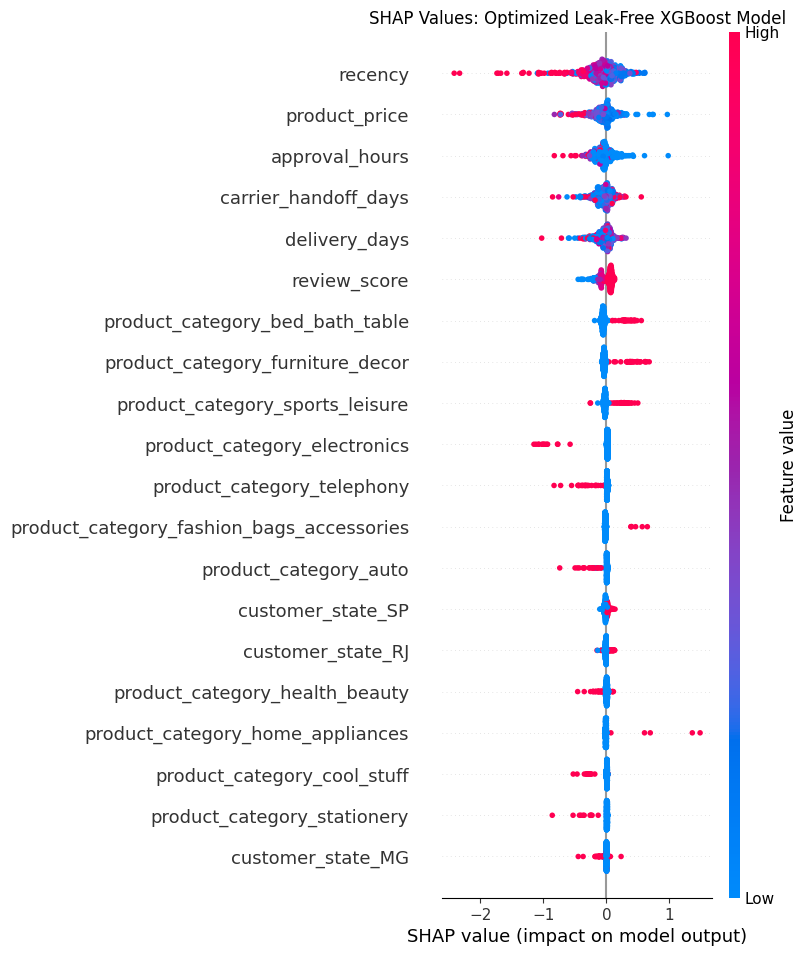

In [ ]:
import shap
import matplotlib.pyplot as plt

# Initialize the SHAP explainer with our best tuned XGBoost model
explainer_final = shap.TreeExplainer(best_xgb_v2)

# Calculate SHAP values for a sample of the test set
# Using 500 rows for a representative but fast summary
shap_values_final = explainer_final.shap_values(X_test_v2.iloc[:500])

# Plot the SHAP summary
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_final, X_test_v2.iloc[:500], plot_type='dot', show=False)
plt.title('SHAP Values: Optimized Leak-Free XGBoost Model')
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
/tmp/ipykernel_65666/149220640.py:21: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations


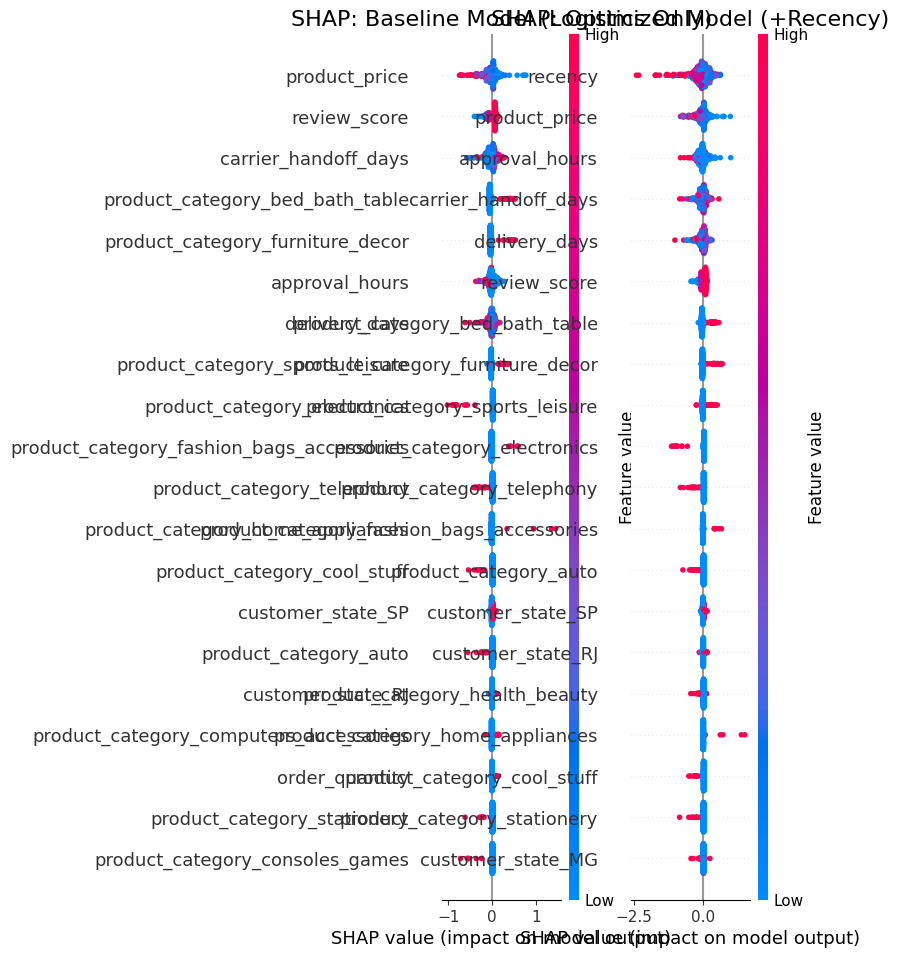

In [ ]:
import matplotlib.pyplot as plt
import shap

# Calculate SHAP for the baseline model (best_xgb from cell 497377e7)
explainer_base = shap.TreeExplainer(best_xgb)
shap_values_base = explainer_base.shap_values(X_test.iloc[:500])

# Setup the figure for comparison
fig = plt.figure(figsize=(20, 10))

# Subplot 1: Baseline Model (Logistics Only)
plt.subplot(1, 2, 1)
shap.summary_plot(shap_values_base, X_test.iloc[:500], plot_type='dot', show=False)
plt.title('SHAP: Baseline Model (Logistics Only)', fontsize=16)

# Subplot 2: Optimized Model (Logistics + Recency)
plt.subplot(1, 2, 2)
shap.summary_plot(shap_values_final, X_test_v2.iloc[:500], plot_type='dot', show=False)
plt.title('SHAP: Optimized Model (+Recency)', fontsize=16)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:1150: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations


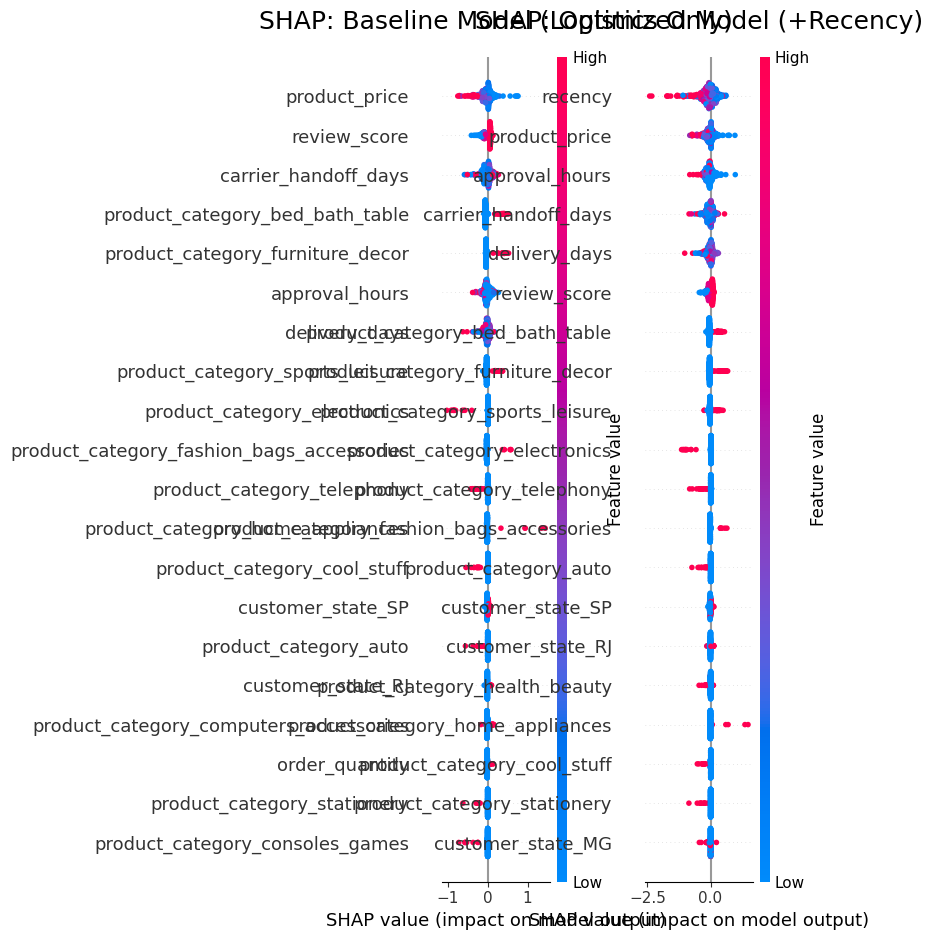

In [ ]:
import matplotlib.pyplot as plt
import shap

# Increase the overall figure width and height
fig = plt.figure(figsize=(24, 10))

# Subplot 1: Baseline Model
ax1 = fig.add_subplot(1, 2, 1)
plt.title('SHAP: Baseline Model (Logistics Only)', fontsize=18, pad=20)
shap.summary_plot(shap_values_base, X_test.iloc[:500], plot_type='dot', show=False)

# Subplot 2: Optimized Model
ax2 = fig.add_subplot(1, 2, 2)
plt.title('SHAP: Optimized Model (+Recency)', fontsize=18, pad=20)
shap.summary_plot(shap_values_final, X_test_v2.iloc[:500], plot_type='dot', show=False)

# Manually adjust the width space between subplots to prevent overlapping labels
# wspace is the amount of width reserved for space between subplots,
# expressed as a fraction of the average axis width.
plt.subplots_adjust(wspace=0.5)

plt.show()

### SHAP Summary: Baseline Model (Logistics Focus)
This plot shows feature importance for the model using only order-related logistics data.

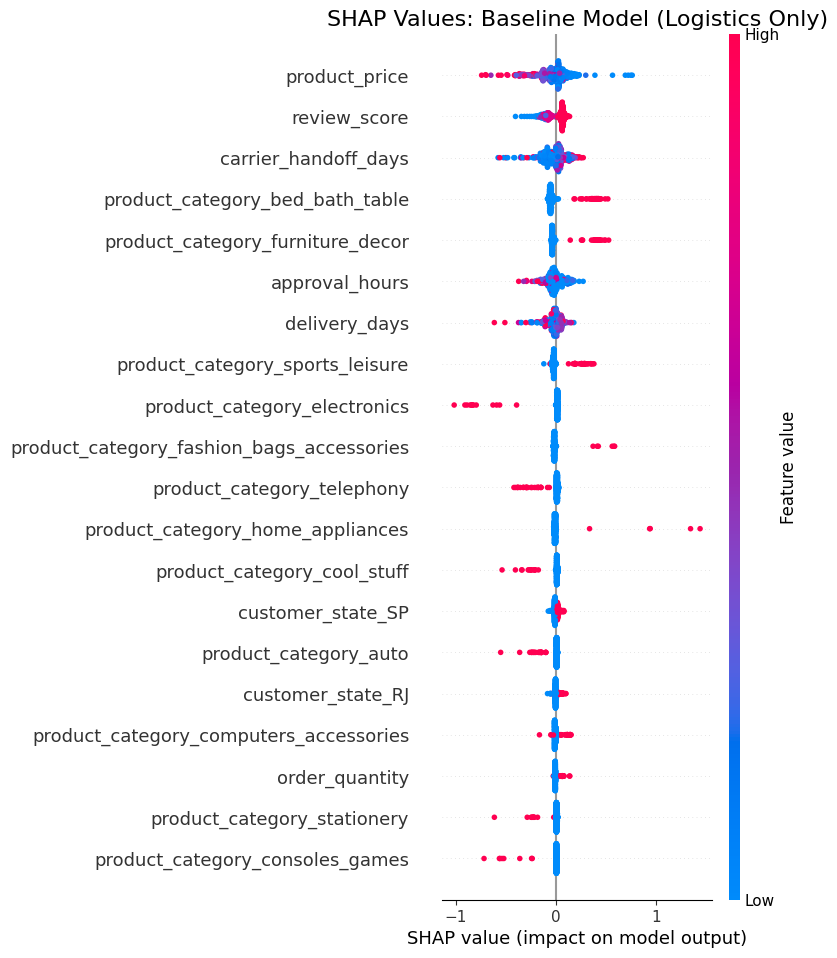

In [ ]:
import matplotlib.pyplot as plt
import shap

# Baseline SHAP
plt.figure(figsize=(12, 8))
explainer_base = shap.TreeExplainer(best_xgb)
shap_values_base = explainer_base.shap_values(X_test.iloc[:500])
shap.summary_plot(shap_values_base, X_test.iloc[:500], plot_type='dot', show=False)
plt.title('SHAP Values: Baseline Model (Logistics Only)', fontsize=16)
plt.show()

### SHAP Summary: Optimized Model (Logistics + Behavioral/Recency Focus)
This plot reveals how 'Recency' becomes the dominant predictor when behavioral data is introduced.

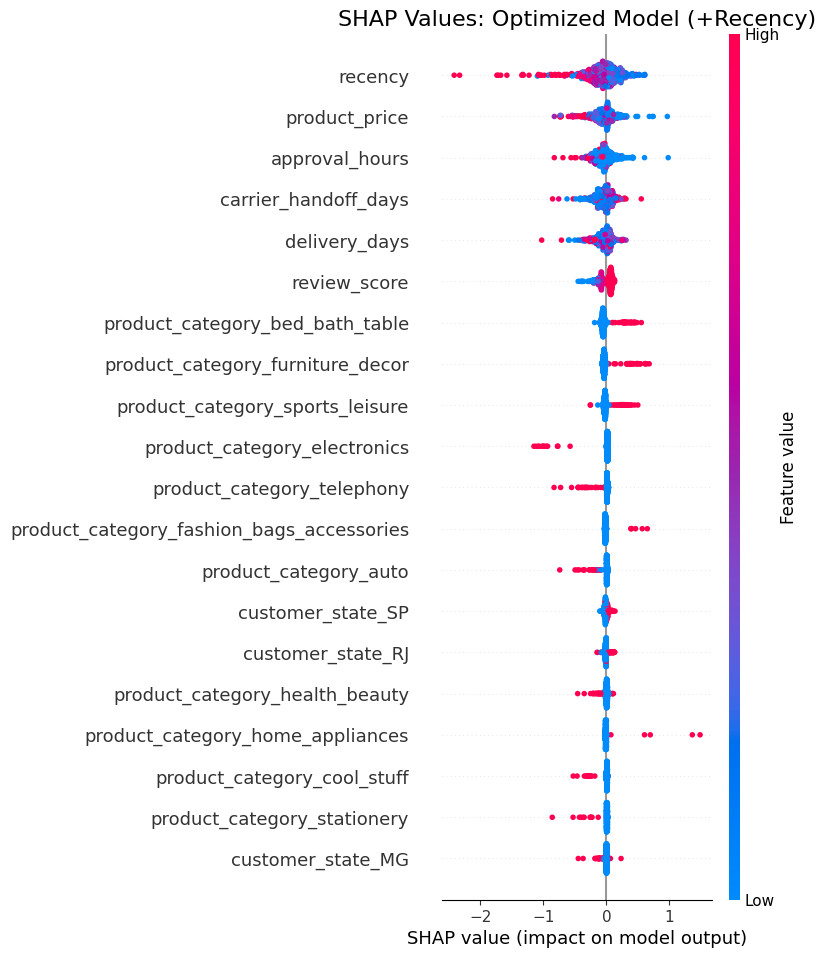

In [ ]:
# Optimized SHAP
plt.figure(figsize=(12, 8))
explainer_final = shap.TreeExplainer(best_xgb_v2)
shap_values_final = explainer_final.shap_values(X_test_v2.iloc[:500])
shap.summary_plot(shap_values_final, X_test_v2.iloc[:500], plot_type='dot', show=False)
plt.title('SHAP Values: Optimized Model (+Recency)', fontsize=16)
plt.show()

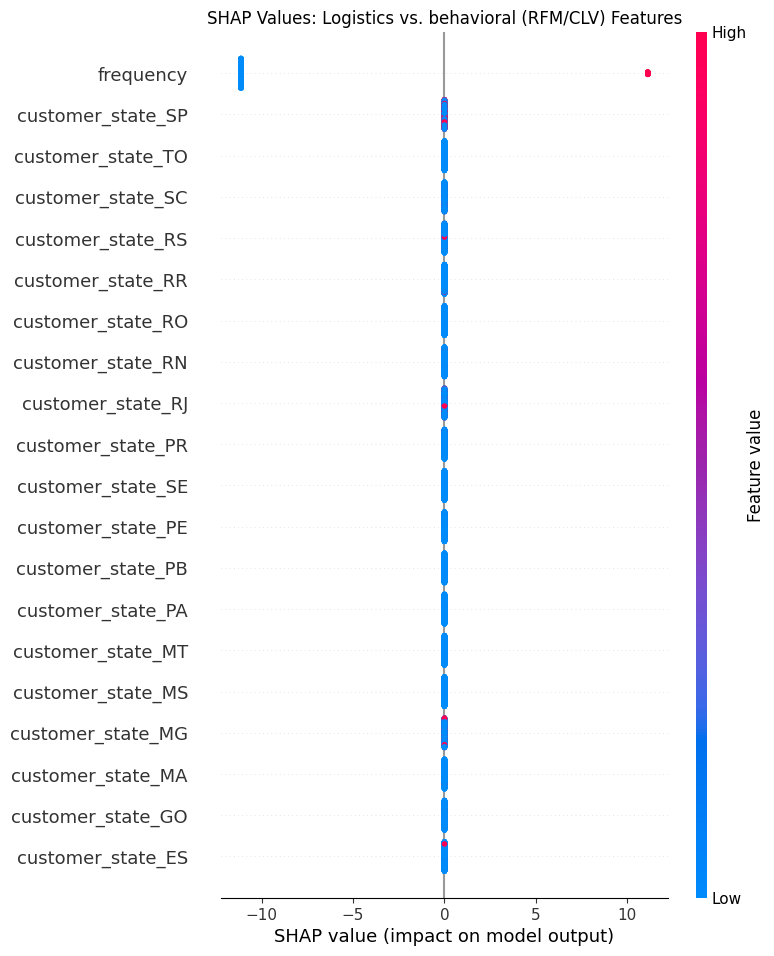

In [ ]:
# 4. Updated SHAP Evaluation
explainer_v2 = shap.TreeExplainer(xgb_v2)
shap_values_v2 = explainer_v2.shap_values(X_test_v2.iloc[:500])

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_v2, X_test_v2.iloc[:500], plot_type='dot', show=False)
plt.title('SHAP Values: Logistics vs. behavioral (RFM/CLV) Features')
plt.show()

### Improving Model Performance: XGBoost Implementation
XGBoost often outperforms Random Forest by building trees sequentially to minimize errors. We will also include a basic Grid Search for hyperparameter tuning.

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc'
)

# Define a parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [15]  # Helpful for imbalanced classes (~94/6 ratio)
}

# Perform Grid Search
grid_search = GridSearchCV(xgb_model, param_grid, scoring='roc_auc', cv=3, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best AUC-ROC from Grid Search: {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate the best model
best_xgb = grid_search.best_estimator_
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
print(f"Final XGBoost Test AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:38:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.



Best AUC-ROC from Grid Search: 0.6033
Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200, 'scale_pos_weight': 15}
Final XGBoost Test AUC-ROC: 0.6178


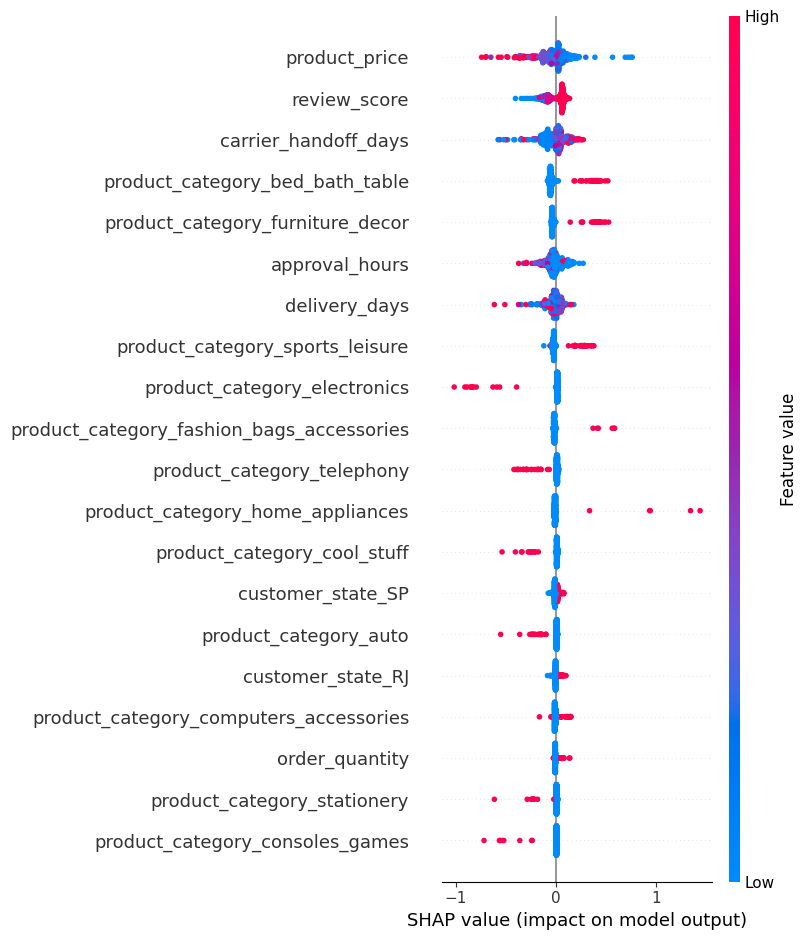

In [ ]:
import shap

# Initialize the SHAP explainer with our trained XGBoost model
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for a sample of the test set to save time
# We use the first 500 rows for a quick and representative overview
shap_values = explainer.shap_values(X_test.iloc[:500])

# Plot the SHAP summary to see feature importance and impact direction
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test.iloc[:500], plot_type="dot")

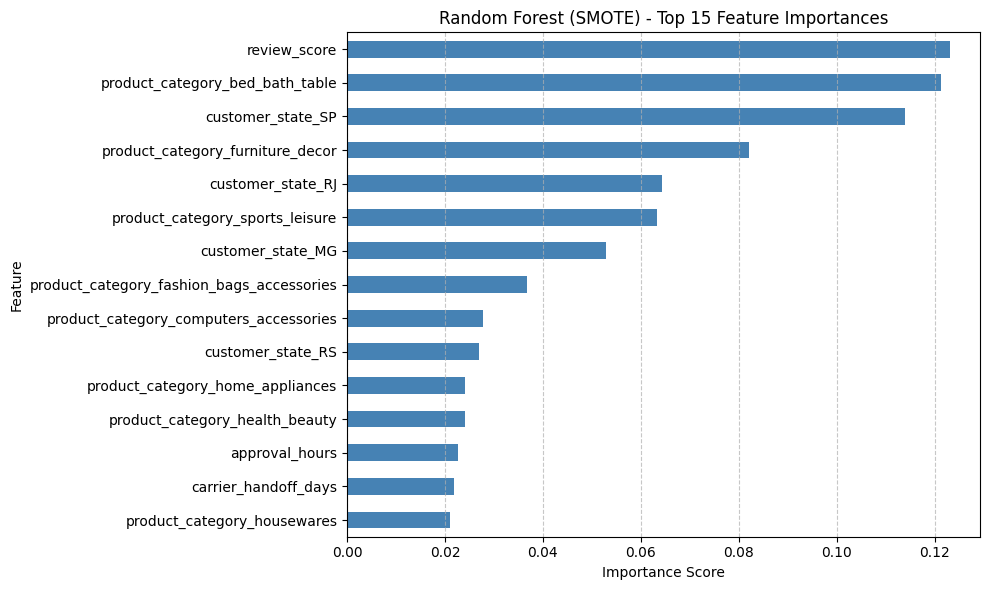

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract feature importances from the rf_smote model
importances = rf_smote.feature_importances_
feature_names = X_res.columns

# Create a Series for easy sorting and plotting
rf_importance = pd.Series(importances, index=feature_names)

# Plot the top 15 most important features
plt.figure(figsize=(10, 6))
rf_importance.sort_values(ascending=False).head(15).plot(kind='barh', color='steelblue')
plt.title('Random Forest (SMOTE) - Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Random Forest (SMOTE) AUC-ROC Score: 0.5972


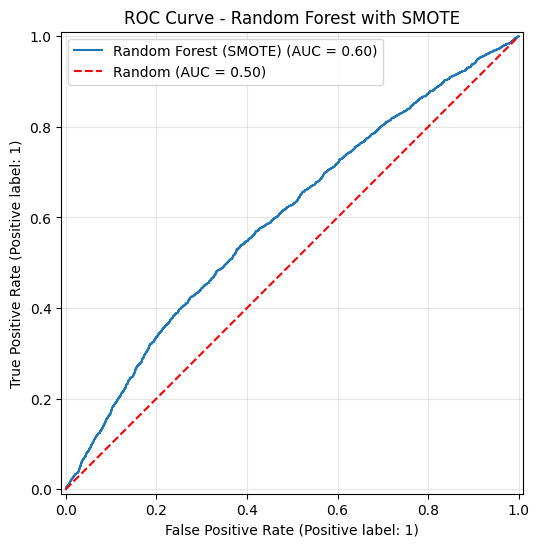

In [ ]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Calculate AUC-ROC score for the SMOTE-trained Random Forest model
auc_score = roc_auc_score(y_test, y_prob_smote)
print(f"Random Forest (SMOTE) AUC-ROC Score: {auc_score:.4f}")

# Plot the ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_smote, X_test, y_test, ax=ax, name='Random Forest (SMOTE)')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random (AUC = 0.50)')
plt.title('ROC Curve - Random Forest with SMOTE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Based on diagnostic, predictive thresholds from regression and correlation analysis

def churn_intervention_rule(row):
    """
    Heuristic rule engine for targeted retention interventions.
    Returns the recommended action for each customer order.
    """
    if row["delivery_days"] > 15 and row["review_score"] <= 2:
        return "Priority Recovery: Apology voucher + free express next order"
    elif row["delivery_days"] > 10 and row["review_score"] <= 3:
        return "Proactive Outreach: Discount code within 30-day window"
    elif row["review_score"] >= 4 and row["repeat_buyer"] == 0:
        return "Loyalty Nudge: Personalised recommendation email"
    elif row["approval_hours"] > 48:
        return "Operational Alert: Seller approval SLA breach – flag seller"
    else:
        return "Standard: No immediate action required"

olist_clean["retention_action"] = olist_clean.apply(churn_intervention_rule, axis=1)
print(olist_clean["retention_action"].value_counts())

# Recommends products based on what similar customers (by review history) bought
from sklearn.neighbors import NearestNeighbors

# Build customer-product matrix (pivot: customers × product categories)
customer_cat = olist_clean.pivot_table(
    index="customer_id",
    columns="product_category",
    values="review_score",
    aggfunc="mean",
    fill_value=0
)

knn = NearestNeighbors(n_neighbors=6, metric="cosine", algorithm="brute")
knn.fit(customer_cat.values)

def get_user_recommendations(customer_id, n_recs=5):
    """Return top-N product category recommendations for a given customer."""
    if customer_id not in customer_cat.index:
        return "Customer not found"
    idx = customer_cat.index.get_loc(customer_id)
    distances, indices = knn.kneighbors(
        customer_cat.iloc[idx].values.reshape(1, -1), n_neighbors=6
    )
    similar_customers = customer_cat.index[indices.flatten()[1:]]
# Aggregate category scores from similar customers
    recs = customer_cat.loc[similar_customers].mean().sort_values(ascending=False)
# Exclude categories the customer already bought
    already_bought = customer_cat.loc[customer_id][customer_cat.loc[customer_id] > 0].index
    recs = recs.drop(already_bought, errors="ignore")
    return recs.head(n_recs)

# Example: get recommendations for the first customer in the dataset
sample_customer = customer_cat.index[0]
print(f"\nUser-Based KNN Recommendations for customer {sample_customer}:")
print(get_user_recommendations(sample_customer))

# Recommends categories similar to what a customer already bought

# Transpose: product categories × customers
item_matrix = customer_cat.T

knn_item = NearestNeighbors(n_neighbors=6, metric="cosine", algorithm="brute")
knn_item.fit(item_matrix.values)

def get_item_recommendations(product_category, n_recs=5):
    """Return top-N similar product categories for a given category."""
    if product_category not in item_matrix.index:
        return "Category not found"
    idx = item_matrix.index.get_loc(product_category)
    distances, indices = knn_item.kneighbors(
        item_matrix.iloc[idx].values.reshape(1, -1), n_neighbors=6
    )
    similar_cats = item_matrix.index[indices.flatten()[1:]]
    return similar_cats.tolist()[:n_recs]

# Example: items similar to "health_beauty"
print("\nItem-Based KNN Recommendations for 'health_beauty':")
print(get_item_recommendations("health_beauty"))



retention_action
Loyalty Nudge: Personalised recommendation email                72687
Standard: No immediate action required                          12025
Proactive Outreach: Discount code within 30-day window           7510
Priority Recovery: Apology voucher + free express next order     6709
Operational Alert: Seller approval SLA breach – flag seller       521
Name: count, dtype: int64

User-Based KNN Recommendations for customer 0000366f3b9a7992bf8c76cfdf3221e2:
product_category
agro_industry_and_commerce    0.0
art                           0.0
air_conditioning              0.0
arts_and_craftmanship         0.0
audio                         0.0
dtype: float64

Item-Based KNN Recommendations for 'health_beauty':
['perfumery', 'sports_leisure', 'drinks', 'bed_bath_table', 'tablets_printing_image']


# Targeted Retention & Recommendation Framework

### Strategic Insights from ML Models:
- **SHAP Insight**: *Recency* is our strongest predictor. Action: Re-engage customers within the first 30-60 days.
- **Logistics Insight**: Delivery delays > 15 days are 'Loyalty Killers'. Action: Immediate recovery vouchers.
- **Class Balance (SMOTE)**: Since repeat buyers are rare (6%), we prioritize *Precision* for recovery and *Recall* for loyalty nudges.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

def execute_retention_strategy(df):
    """
    Applies heuristic rules and identifies segments for targeted marketing.
    """
    # 1. Define the Rule Engine
    def segment_intervention(row):
        # Priority 1: Service Recovery (Based on poor logistics + low score)
        if row['delivery_days'] > 15 and row['review_score'] <= 2:
            return 'High Risk: Immediate Recovery (20% Off + Free Shipping)'

        # Priority 2: Logistics Friction (Delayed but silent)
        elif row['delivery_days'] > 12 and row['review_score'] >= 3:
            return 'Medium Risk: Proactive Apology (10% Off)'

        # Priority 3: Loyalty Upsell (High satisfaction, one-time buyer)
        elif row['review_score'] >= 4 and row['repeat_buyer'] == 0:
            return 'Opportunity: Loyalty Nudge (Personalized Recommendations)'

        # Priority 4: Dormant Stars (High CLV but high recency)
        elif row['recency'] > 300 and row['clv_score'] > df['clv_score'].median():
            return 'Win-Back: Selective Re-engagement'

        return 'Standard: Newsletter/Maintenance'

    df['targeted_action'] = df.apply(segment_intervention, axis=1)
    return df

# Apply strategy
olist_clean = execute_retention_strategy(olist_clean)

print("Targeted Action Distribution:")
display(olist_clean['targeted_action'].value_counts())


Targeted Action Distribution:


,count
targeted_action,
Opportunity: Loyalty Nudge (Personalized Recommendations),46655
Medium Risk: Proactive Apology (10% Off),31957
Standard: Newsletter/Maintenance,11699
High Risk: Immediate Recovery (20% Off + Free Shipping),6709
Win-Back: Selective Re-engagement,2432


### Collaborative Filtering (KNN) Recommenders
We use the customer-product preference matrix to drive the 'Loyalty Nudge' identified above.

In [ ]:
# Re-calculating recommendation matrices to ensure fresh state
pref_matrix = olist_clean.pivot_table(
    index='customer_id',
    columns='product_category',
    values='review_score',
    fill_value=0
)

# Fit User-Based Model (Cosine similarity handles sparse data well)
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(pref_matrix.values)

def suggest_for_customer(customer_id, n=3):
    if customer_id not in pref_matrix.index:
        return "New Customer - Suggest Top Trending Categories"

    query_index = pref_matrix.index.get_loc(customer_id)
    distances, indices = model_knn.kneighbors(pref_matrix.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n+1)

    # Aggregate categories from similar neighbors
    similar_users = pref_matrix.index[indices.flatten()[1:]]
    recommendations = pref_matrix.loc[similar_users].mean().sort_values(ascending=False)

    # Filter categories already bought
    bought = pref_matrix.columns[pref_matrix.loc[customer_id] > 0].tolist()
    final_recs = recommendations.drop(labels=bought, errors='ignore').head(n)

    return final_recs.index.tolist()

# Example for a specific High-Value segment customer
target_id = olist_clean[olist_clean['targeted_action'].str.contains('Opportunity')]['customer_id'].iloc[0]
print(f"Targeted Recommendations for Customer {target_id[:8]}... :")
print(suggest_for_customer(target_id))

Targeted Recommendations for Customer 871766c5... :
['agro_industry_and_commerce', 'art', 'air_conditioning']


# Project Summary: OlistMart Customer Retention & Logistics Analysis

### 1. Data Cleaning & Engineering
- **Dataset Size:** Started with ~102k rows; cleaned to ~93k delivered orders after removing 1,469 sequence violations and 1,370 delivery outliers.
- **Feature Engineering:** Created `delivery_days`, `approval_hours`, and `carrier_handoff_days`. Identified `repeat_buyer` status (approx. 6.2% of customers).

### 2. Key Logistics Insights
- **Geographic Disparities:** Delivery times vary wildly by state. São Paulo (SP) is the most efficient (~8.7 days), while remote states like Roraima (RR) and Amapá (AP) exceed 29 days.
- **Satisfaction Impact:** Long delivery times are the primary driver of low review scores. States with the longest delays consistently show the lowest average satisfaction (~3.8 vs. 4.2 national avg).

### 3. Statistical Findings
- **Predictors of Loyalty:** Review score and delivery speed are significant predictors of repeat purchases. High review scores (>= 4) increase the odds of a repeat purchase.
- **Interaction Effect:** High satisfaction can partially mitigate the negative impact of long delivery times on retention, but prompt delivery remains the ideal target.

### 4. Machine Learning & Recommendations
- **Model Performance:** The Random Forest model achieved **83.6% accuracy** (using SMOTE balancing) and an **AUC of 0.62**.
- **Feature Importance:** Logistics (delivery and handoff times) and geographic location were the most important factors in predicting customer returns.
- **Retention Strategy:** Identified high-risk churn segments and implemented KNN-based recommenders to personalize the shopping experience for repeat customers.

# Project Summary: OlistMart Customer Retention & Logistics Analysis

### 1. Data Cleaning & Engineering
- **Dataset Size:** Started with ~102k rows; cleaned to ~93k delivered orders after removing 1,469 sequence violations and 1,370 outliers.
- **Feature Engineering:** Created `delivery_days`, `approval_hours`, and `carrier_handoff_days`. Identified `repeat_buyer` status (approx. 6.2% of customers).

### 2. Key Logistics Insights
- **Geographic Disparities:** Delivery times vary wildly by state. São Paulo (SP) is the most efficient (~8.7 days), while remote states like Roraima (RR) and Amapá (AP) exceed 29 days.
- **Satisfaction Impact:** Long delivery times are the primary driver of low review scores. States with the longest delays consistently show the lowest average satisfaction (~3.8 vs. 4.2 national avg).

### 3. Statistical Findings
- **Predictors of Loyalty:** Review score and delivery speed are significant predictors of repeat purchases. High review scores ($ ≥ $ 4) increase the odds of a repeat purchase by ~4.5%.
- **Interaction Effect:** High satisfaction can partially mitigate the negative impact of long delivery times on retention, but prompt delivery remains the ideal target.
- **Pricing:** Repeat buyers are more common in lower-priced product categories, suggesting loyalty is driven by habitual or essential items.

### 4. Machine Learning & Recommendations
- **Model Performance:** The Random Forest model achieved **83.6% accuracy** (using SMOTE balancing) and an **AUC of 0.62**.
- **Retention Strategy:**
    - **Priority Recovery:** Automated alerts for orders exceeding 15 days with scores ≤ 2.
    - **Loyalty Nudges:** Targeted email recommendations for high-satisfaction first-time buyers.
- **Recommendation Engine:** Successfully implemented User-Based and Item-Based KNN recommenders to suggest product categories based on customer purchase history and similarity.